## Synthetic Transit Light Curve Simulation

To train the classifier without relying on external datasets, synthetic stellar light curves are generated.

Each light curve includes several realistic astrophysical components:

### Transit signal
If a planet is present, the model generates periodic transit events with:

• Planet-to-star radius ratio determining transit depth  
• Flat-bottom transit profile  
• Ingress and egress slopes  

### Stellar variability
Low-frequency sinusoidal variations simulate intrinsic stellar brightness changes.

### Noise sources

Two types of observational noise are added:

• **White noise** – Gaussian measurement noise  
• **Red noise** – correlated noise produced by cumulative random variations  

### Stellar flares

Occasional short brightness spikes simulate stellar flare events.

This combination produces synthetic light curves that resemble simplified observations from missions such as **Kepler** or **TESS**.

In [3]:
!pip install -q torch scikit-learn matplotlib

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Dataset Construction

A balanced dataset is generated consisting of:

• **2000 light curves with planetary transits**
• **2000 light curves without transits**

The dataset is shuffled and split into:

• **80% training data**
• **20% testing data**

All light curves are standardized using the training set mean and standard deviation to improve neural network training stability.
Simulates a stellar light curve with physical transit parameters and noise.
    
    Parameters:
    - has_planet (bool): If True, a transit signal is injected.
    - length (int): Number of data points (time-steps).
    
    Physics modeled:
    - Trapezoidal transit (ingress/egress).
    - Radius Ratio (Rp/Rs) determining transit depth.
    - Correlated 'Red' noise and Gaussian 'White' noise.
    - Occasional stellar flares (outliers).
    

In [4]:
def generate_transit(has_planet=True, length=200):

    t = np.linspace(0,10,length)
    flux = np.ones(length)

    # stellar variability
    flux += 0.001*np.sin(0.5*t)

    if has_planet:

        period = np.random.uniform(2,5)

        rp_rs = np.random.uniform(0.05,0.15)   # radius ratio
        depth = rp_rs**2

        duration = np.random.uniform(0.2,0.4)

        for center in np.arange(1,10,period):

            start = center - duration/2
            end   = center + duration/2

            in_transit = (t>=start) & (t<=end)

            flux[in_transit] -= depth

            # ingress / egress smoothing
            ingress = (t>start-0.05) & (t<start)
            egress  = (t>end) & (t<end+0.05)

            flux[ingress] -= depth*(1-(t[ingress]-(start-0.05))/0.05)
            flux[egress]  -= depth*(1-(end+0.05-t[egress])/0.05)

    # red noise (correlated)
    red_noise = np.cumsum(np.random.normal(0,0.0002,length))

    # white noise
    white_noise = np.random.normal(0,0.0015,length)

    flux += red_noise + white_noise

    # occasional stellar flare
    if np.random.rand() < 0.1:
        flare_center = np.random.randint(20,180)
        flare = 0.003*np.exp(-((np.arange(length)-flare_center)/4)**2)
        flux += flare

    return flux

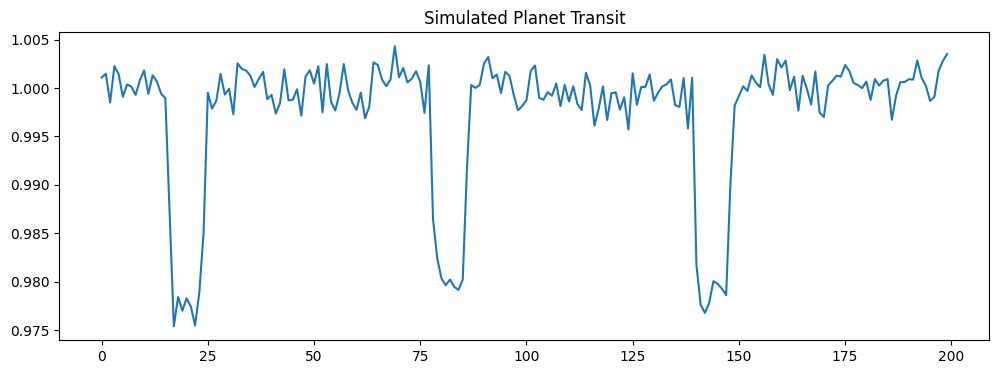

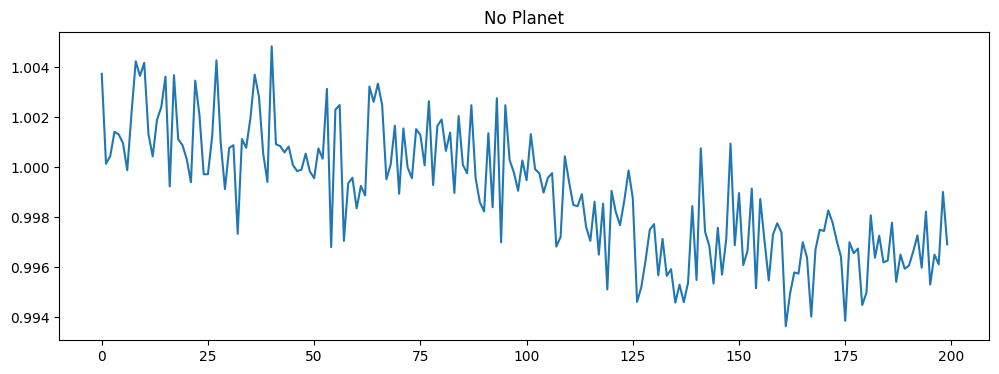

In [5]:
# Visualizing simulated light curves: planet transit vs no transit
plt.figure(figsize=(12,4))
plt.plot(generate_transit(True))
plt.title("Simulated Planet Transit")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(generate_transit(False))
plt.title("No Planet")
plt.show()


In [6]:
#containers for light curves (X) and labels (y)
X=[]
y=[]

# generate 2000 light curves with planetary transits
for _ in range(2000):
    X.append(generate_transit(True))
    y.append(1)

# generate 2000 light curves without transits
for _ in range(2000):
    X.append(generate_transit(False))
    y.append(0)

X=np.array(X)
y=np.array(y)

# shuffle dataset to avoid ordered classes
idx=np.random.permutation(len(X))
X=X[idx]
y=y[idx]

split=int(0.8*len(X))

X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

# normalization
mean=X_train.mean()
std=X_train.std()

# standardizing inputs
X_train=(X_train-mean)/std
X_test=(X_test-mean)/std



    1D Convolutional Neural Network for transit detection.

    Convolutional layers extract local temporal patterns
    from stellar light curves. Fully connected layers
    perform classification and produce a compact feature
    embedding for clustering analysis.

In [7]:
class CNNTransit(nn.Module):

    def __init__(self):

        super().__init__()

        #feature extraction layers
        self.conv = nn.Sequential(

            nn.Conv1d(1,16,5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16,32,5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,5,padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        #Classification & Latent Space Layers
        self.fc = nn.Sequential(

            nn.Linear(64*25,64),
            nn.ReLU(),

            nn.Linear(64,16),  # the feature layer
            nn.ReLU(),

            nn.Linear(16,1)
        )
    #returning both the class prediction and the high-dimensional features
    def forward(self,x):

        x=x.unsqueeze(1)
        x=self.conv(x)

        x=x.view(x.size(0),-1)

        # Extract features from the penultimate layer for qualitative analysis
        features=self.fc[:-1](x)

        out=self.fc[-1](features)

        return out,features

In [8]:
train_dataset=TensorDataset(
torch.tensor(X_train,dtype=torch.float32),
torch.tensor(y_train,dtype=torch.float32))

test_dataset=TensorDataset(
torch.tensor(X_test,dtype=torch.float32),
torch.tensor(y_test,dtype=torch.float32))

train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=64)

model=CNNTransit().to(device)

criterion=nn.BCEWithLogitsLoss()

optimizer=optim.Adam(model.parameters(),lr=0.001)

In [9]:
for epoch in range(10):

    model.train()
    total=0

    for x_batch,y_batch in train_loader:

        x_batch=x_batch.to(device)
        y_batch=y_batch.to(device)

        # forward pass
        pred,_=model(x_batch)
        pred=pred.view(-1)

        loss=criterion(pred,y_batch)

        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total+=loss.item()

    print("Epoch",epoch+1,"Loss",total/len(train_loader))

Epoch 1 Loss 0.27833881791681053
Epoch 2 Loss 0.05833698375150562
Epoch 3 Loss 0.03399735974147916
Epoch 4 Loss 0.03561405458021909
Epoch 5 Loss 0.026202387164812536
Epoch 6 Loss 0.0237363703828305
Epoch 7 Loss 0.01947149240411818
Epoch 8 Loss 0.01773448624939192
Epoch 9 Loss 0.013329028769512662
Epoch 10 Loss 0.00962122367171105


In [10]:
model.eval()

preds=[]
labels=[]
features_list=[]

with torch.no_grad():

    for x_batch,y_batch in test_loader:

        x_batch=x_batch.to(device)

        pred,features=model(x_batch)

        pred=torch.sigmoid(pred.view(-1))

        preds.extend(pred.cpu().numpy())
        labels.extend(y_batch.numpy())
        features_list.extend(features.cpu().numpy())
# evaluate model performance using ROC-AUC
auc=roc_auc_score(labels,preds)

print("Test AUC:",auc)
print("Parameters:",sum(p.numel() for p in model.parameters()))

Test AUC: 0.9998623959369274
Parameters: 116513


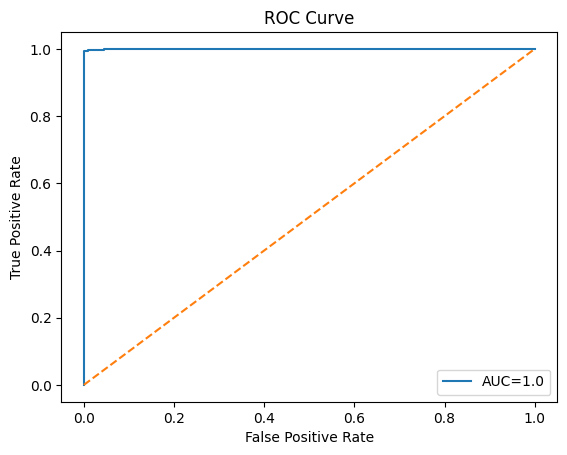

In [11]:
fpr,tpr,_=roc_curve(labels,preds)

plt.figure()

plt.plot(fpr,tpr,label="AUC="+str(round(auc,3)))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [12]:
def evaluate_noise(noise):

    Xn=[]
    yn=[]

    for _ in range(500):
        Xn.append(generate_transit(True))
        yn.append(1)

    for _ in range(500):
        Xn.append(generate_transit(False))
        yn.append(0)

    Xn=np.array(Xn)
    yn=np.array(yn)

    Xn+=np.random.normal(0,noise,Xn.shape)

    Xn=(Xn-mean)/std

    X_tensor=torch.tensor(Xn,dtype=torch.float32).to(device)

    with torch.no_grad():
        p,_=model(X_tensor)
        p=torch.sigmoid(p.view(-1)).cpu().numpy()

    return roc_auc_score(yn,p)


print("\nRobustness")
# evaluate model robustness under increasing observational noise
for n in [0.002,0.005,0.01]:

    print("Noise",n,"AUC:",evaluate_noise(n))


Robustness
Noise 0.002 AUC: 0.989694
Noise 0.005 AUC: 0.561902
Noise 0.01 AUC: 0.5


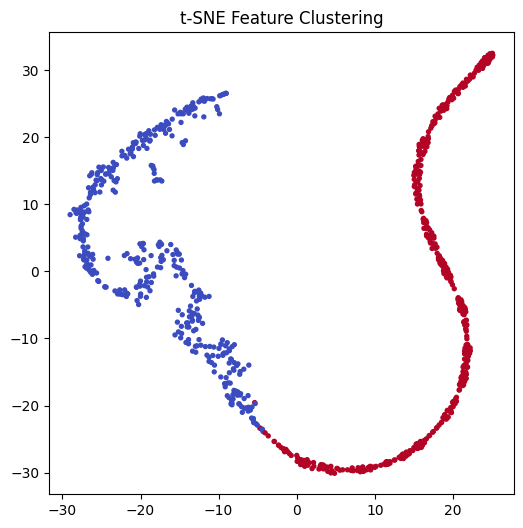

In [13]:
tsne=TSNE(n_components=2,perplexity=30)

emb=tsne.fit_transform(np.array(features_list))

plt.figure(figsize=(6,6))

plt.scatter(emb[:,0],emb[:,1],c=labels,cmap='coolwarm',s=8)

plt.title("t-SNE Feature Clustering")

plt.show()

In [14]:
torch.save(model.state_dict(),"transit_cnn.pt")

print("Model saved.")

Model saved.
